In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

merged_df = pd.read_csv("merged_scores_imu.csv")
print(merged_df.shape)
merged_df.head()

(117, 13)


,file_name,path,n_rows,stroke_type_x,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,評語,stroke_type_y,平推為正手或反手
0,10281挑,1028/10281挑.txt,11500,挑,10281挑,5,5,5,5,5,NaN,挑,NaN
1,10281推,1028/10281推.txt,10600,推,10281推,5,4,5,5,5,NaN,推,反手
2,10282挑,1028/10282挑.txt,12600,挑,10282挑,4,3,3,3,4,揮拍速度可再加快，擊球時手腕角度不夠正,挑,NaN
3,10282推,1028/10282推.txt,10800,推,10282推,5,3,3,3,4,揮拍不夠流暢、手腕太慢出力,推,反手
4,10283挑,1028/10283挑.txt,10600,挑,10283挑,5,5,4,4,5,擊球時間點太慢，導致都未在最甜蜜點擊到球,挑,NaN


In [2]:
def convert_score_to_category(score):
    score = int(score)
    return (score - 1) // 2   # 1,2->0 ; 3,4->1 ; 5->2

score_cols = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

for col in score_cols:
    merged_df[col + "_cat"] = merged_df[col].apply(convert_score_to_category)

display(
    merged_df[[
        "file_name",
        "揮拍軌跡正確度", "揮拍軌跡正確度_cat",
        "揮拍速度流暢度", "揮拍速度流暢度_cat",
        "手腕轉動時機正確度", "手腕轉動時機正確度_cat"
    ]].head()
)

,file_name,揮拍軌跡正確度,揮拍軌跡正確度_cat,揮拍速度流暢度,揮拍速度流暢度_cat,手腕轉動時機正確度,手腕轉動時機正確度_cat
0,10281挑,5,2,5,2,5,2
1,10281推,5,2,4,1,5,2
2,10282挑,4,1,3,1,3,1
3,10282推,5,2,3,1,3,1
4,10283挑,5,2,5,2,4,1


In [3]:
def load_imu_txt(txt_path):
    df = pd.read_csv(txt_path, header=None)
    df.columns = ["t1", "acc_x", "acc_y", "acc_z", "t2", "gyro_x", "gyro_y", "gyro_z"]
    df = df[["t1", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]]
    df = df.rename(columns={"t1": "time"})
    return df

In [4]:
sample_path = merged_df.iloc[0]["path"]
imu_df = load_imu_txt(sample_path)

print(sample_path)
print(imu_df.shape)
imu_df.head()

1028/10281挑.txt
(11500, 7)


,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,10,5.126,2.040,7.314,-0.100,-0.118,0.166
1,20,6.532,0.372,6.760,-0.226,-0.076,0.046
2,30,7.108,3.164,7.628,-0.280,0.024,0.062
3,40,6.008,4.374,8.278,-0.310,0.130,0.118
4,50,5.334,3.270,7.944,-0.344,0.168,0.020


In [5]:
import numpy as np

def resample_imu_array(arr, target_len=100):
    old_len = arr.shape[0]
    old_idx = np.linspace(0, 1, old_len)
    new_idx = np.linspace(0, 1, target_len)

    out = np.zeros((target_len, arr.shape[1]))
    for i in range(arr.shape[1]):
        out[:, i] = np.interp(new_idx, old_idx, arr[:, i])
    return out

X_list = []

for _, row in merged_df.iterrows():
    imu_df = load_imu_txt(row["path"])
    imu_values = imu_df[["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]].values
    imu_resampled = resample_imu_array(imu_values, target_len=100)
    X_list.append(imu_resampled)

X = np.array(X_list)
print("X shape:", X.shape)

X shape: (117, 100, 6)


In [6]:
y1 = merged_df["揮拍軌跡正確度_cat"].values
y2 = merged_df["揮拍速度流暢度_cat"].values
y3 = merged_df["手腕轉動時機正確度_cat"].values
y4 = merged_df["擊球時機正確度_cat"].values
y5 = merged_df["擊球位置正確度_cat"].values

print("y1 shape:", y1.shape, "classes:", np.unique(y1))
print("y2 shape:", y2.shape, "classes:", np.unique(y2))
print("y3 shape:", y3.shape, "classes:", np.unique(y3))
print("y4 shape:", y4.shape, "classes:", np.unique(y4))
print("y5 shape:", y5.shape, "classes:", np.unique(y5))

y1 shape: (117,) classes: [0 1 2]
y2 shape: (117,) classes: [0 1 2]
y3 shape: (117,) classes: [0 1 2]
y4 shape: (117,) classes: [0 1 2]
y5 shape: (117,) classes: [0 1 2]


In [7]:
import tensorflow as tf

model1 = tf.keras.models.load_model("專題/models/model1.keras")
model1.summary()

I0000 00:00:1778676994.918669   67144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676994.928237   67144 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778676996.389288   67144 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778677002.767558   67144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,571 (17.86 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,048 (11.91 KB)

In [8]:
pred1 = model1.predict(X)
print(pred1.shape)
print(pred1[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
(117, 3)
[[0.23360723 0.42842335 0.3379694 ]
 [0.19730163 0.4795081  0.3231902 ]
 [0.4354063  0.36051625 0.20407751]
 [0.35190266 0.38786462 0.26023272]
 [0.38034347 0.33034742 0.28930917]]


In [9]:
pred1_class = np.argmax(pred1, axis=1)

print(pred1_class[:10])
print("pred classes:", np.unique(pred1_class))
print("true classes:", np.unique(y1))

[1 1 0 1 0 1 0 1 1 1]
pred classes: [0 1 2]
true classes: [0 1 2]


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc1 = accuracy_score(y1, pred1_class)
print("model1 accuracy on trajectory:", acc1)

print("\nclassification report:")
print(classification_report(y1, pred1_class))

print("\nconfusion matrix:")
print(confusion_matrix(y1, pred1_class))

model1 accuracy on trajectory: 0.29914529914529914

classification report:
              precision    recall  f1-score   support

           0       0.20      0.47      0.28        17
           1       0.36      0.63      0.46        43
           2       0.00      0.00      0.00        57

    accuracy                           0.30       117
   macro avg       0.19      0.37      0.25       117
weighted avg       0.16      0.30      0.21       117


confusion matrix:
[[ 8  7  2]
 [16 27  0]
 [17 40  0]]


## 忘記把挑球和平推球分開，現在分開

In [11]:
lift_idx = merged_df["stroke_type_x"] == "挑"
push_idx = merged_df["stroke_type_x"] == "推"

# 分開 X
X_lift = X[lift_idx]
X_push = X[push_idx]

# 分開 y（先用 model1 對應的 y1）
y1_lift = y1[lift_idx]
y1_push = y1[push_idx]

print("挑球:", X_lift.shape)
print("平推:", X_push.shape)

挑球: (59, 100, 6)
平推: (58, 100, 6)


### model1 遷移測試

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# 挑球預測
pred1_lift = model1.predict(X_lift)
pred1_lift_class = np.argmax(pred1_lift, axis=1)

print("=== 高遠 model1 -> 挑球 ===")
print("accuracy:", accuracy_score(y1_lift, pred1_lift_class))
print(confusion_matrix(y1_lift, pred1_lift_class))

# 平推預測
pred1_push = model1.predict(X_push)
pred1_push_class = np.argmax(pred1_push, axis=1)

print("\n=== 高遠 model1 -> 平推 ===")
print("accuracy:", accuracy_score(y1_push, pred1_push_class))
print(confusion_matrix(y1_push, pred1_push_class))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
=== 高遠 model1 -> 挑球 ===
accuracy: 0.3389830508474576
[[ 8  4  1]
 [13 12  0]
 [ 9 12  0]]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

=== 高遠 model1 -> 平推 ===
accuracy: 0.25862068965517243
[[ 0  3  1]
 [ 3 15  0]
 [ 8 28  0]]


In [13]:
acc_lift = accuracy_score(y1_lift, pred1_lift_class)
acc_push = accuracy_score(y1_push, pred1_push_class)

print(f"高遠 -> 挑球 accuracy: {acc_lift:.3f}")
print(f"高遠 -> 平推 accuracy: {acc_push:.3f}")
print(f"差值: {(acc_lift - acc_push):.3f}")

高遠 -> 挑球 accuracy: 0.339
高遠 -> 平推 accuracy: 0.259
差值: 0.080


### 全model 遷移測試

In [14]:
import tensorflow as tf
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

model_paths = [
    "專題/models/model1.keras",
    "專題/models/model2.keras",
    "專題/models/model3.keras",
    "專題/models/model4.keras",
    "專題/models/model5.keras",
]

metric_names = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

y_list = [y1, y2, y3, y4, y5]

挑_idx = merged_df["stroke_type_x"] == "挑"
推_idx = merged_df["stroke_type_x"] == "推"

X_挑 = X[挑_idx]
X_推 = X[推_idx]

results = []

models = [tf.keras.models.load_model(p) for p in model_paths]

for model, y_true_all, metric_name in zip(models, y_list, metric_names):
    y_挑 = y_true_all[挑_idx]
    y_推 = y_true_all[推_idx]

    pred_挑 = model.predict(X_挑, verbose=0)
    pred_推 = model.predict(X_推, verbose=0)

    pred_挑_class = np.argmax(pred_挑, axis=1)
    pred_推_class = np.argmax(pred_推, axis=1)

    acc_挑 = accuracy_score(y_挑, pred_挑_class)
    acc_推 = accuracy_score(y_推, pred_推_class)

    results.append({
        "指標": metric_name,
        "高遠_to_挑_acc": acc_挑,
        "高遠_to_推_acc": acc_推,
        "loss rate_挑減推": acc_挑 - acc_推
    })

results_df = pd.DataFrame(results)
display(results_df)

,指標,高遠_to_挑_acc,高遠_to_推_acc,loss rate_挑減推
0,揮拍軌跡正確度,0.338983,0.258621,0.080362
1,揮拍速度流暢度,0.389831,0.448276,-0.058445
2,手腕轉動時機正確度,0.220339,0.362069,-0.141730
3,擊球時機正確度,0.457627,0.275862,0.181765
4,擊球位置正確度,0.423729,0.293103,0.130625


In [15]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
[c for c in fonts if ("Noto" in c) or ("CJK" in c) or ("Hei" in c) or ("JhengHei" in c) or ("Kai" in c)]

['AR PL KaitiM Big5',
 'AR PL KaitiM GB',
 'Noto Mono',
 'Noto Sans CJK JP',
 'Noto Sans Mono',
 'Noto Serif CJK JP']

In [16]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
[c for c in fonts if "Noto Sans CJK" in c][:20]

['Noto Sans CJK JP']

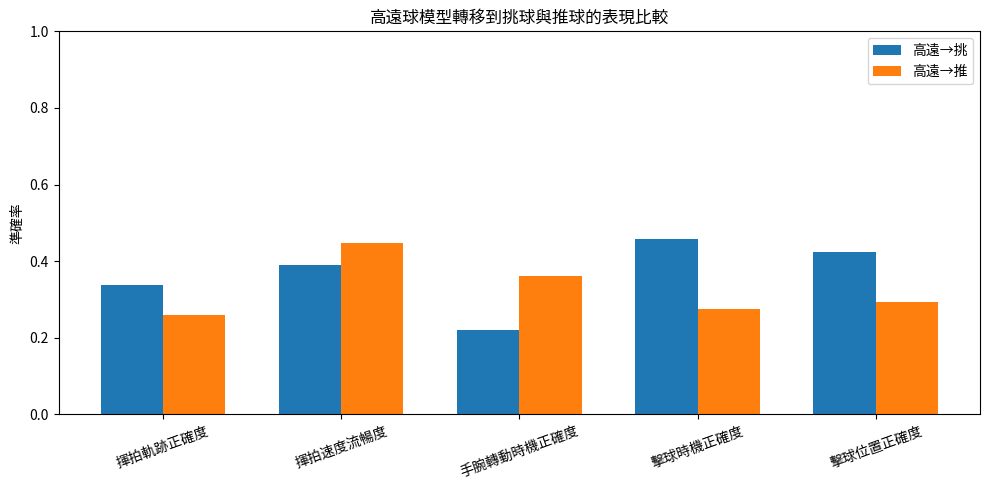

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

plot_df = results_df.copy()

x = np.arange(len(plot_df["指標"]))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["高遠_to_挑_acc"], width, label="高遠→挑")
plt.bar(x + width/2, plot_df["高遠_to_推_acc"], width, label="高遠→推")

plt.xticks(x, plot_df["指標"], rotation=20)
plt.ylabel("準確率")
plt.title("高遠球模型轉移到挑球與推球的表現比較")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

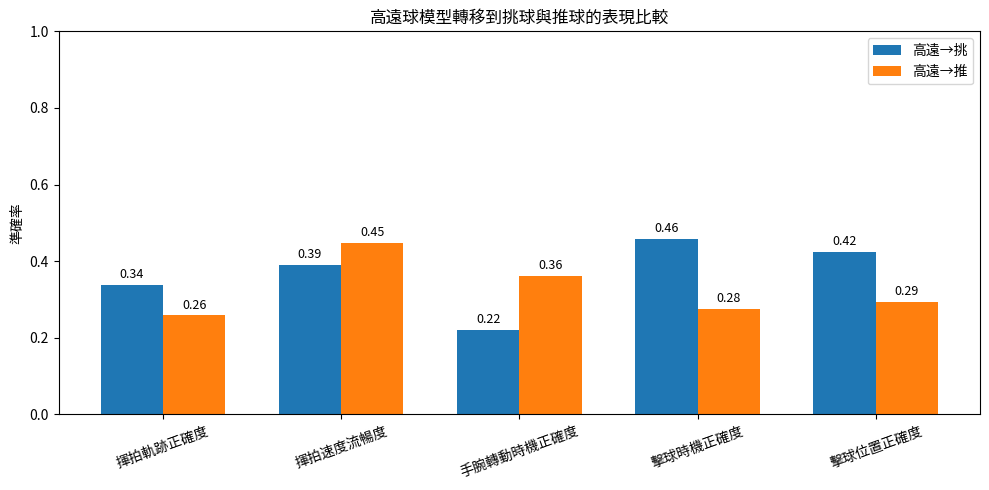

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

plot_df = results_df.copy()

x = np.arange(len(plot_df["指標"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, plot_df["高遠_to_挑_acc"], width, label="高遠→挑")
bars2 = plt.bar(x + width/2, plot_df["高遠_to_推_acc"], width, label="高遠→推")

plt.xticks(x, plot_df["指標"], rotation=20)
plt.ylabel("準確率")
plt.title("高遠球模型轉移到挑球與推球的表現比較")
plt.ylim(0, 1)
plt.legend()

# 👉 加數值標籤
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

## 挑球 self training

In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 固定亂數，方便重現
np.random.seed(42)
tf.random.set_seed(42)

In [20]:
merged_df = pd.read_csv("merged_scores_imu.csv")

print(merged_df.shape)
merged_df.head()

(117, 13)


,file_name,path,n_rows,stroke_type_x,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,評語,stroke_type_y,平推為正手或反手
0,10281挑,1028/10281挑.txt,11500,挑,10281挑,5,5,5,5,5,NaN,挑,NaN
1,10281推,1028/10281推.txt,10600,推,10281推,5,4,5,5,5,NaN,推,反手
2,10282挑,1028/10282挑.txt,12600,挑,10282挑,4,3,3,3,4,揮拍速度可再加快，擊球時手腕角度不夠正,挑,NaN
3,10282推,1028/10282推.txt,10800,推,10282推,5,3,3,3,4,揮拍不夠流暢、手腕太慢出力,推,反手
4,10283挑,1028/10283挑.txt,10600,挑,10283挑,5,5,4,4,5,擊球時間點太慢，導致都未在最甜蜜點擊到球,挑,NaN


In [21]:
def convert_score_to_category(score):
    score = int(score)
    return (score - 1) // 2   # 1,2→0 / 3,4→1 / 5→2

In [22]:
score_cols = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

for col in score_cols:
    merged_df[col + "_cat"] = merged_df[col].apply(convert_score_to_category)

merged_df.head()

,file_name,path,n_rows,stroke_type_x,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,評語,stroke_type_y,平推為正手或反手,揮拍軌跡正確度_cat,揮拍速度流暢度_cat,手腕轉動時機正確度_cat,擊球時機正確度_cat,擊球位置正確度_cat
0,10281挑,1028/10281挑.txt,11500,挑,10281挑,5,5,5,5,5,NaN,挑,NaN,2,2,2,2,2
1,10281推,1028/10281推.txt,10600,推,10281推,5,4,5,5,5,NaN,推,反手,2,1,2,2,2
2,10282挑,1028/10282挑.txt,12600,挑,10282挑,4,3,3,3,4,揮拍速度可再加快，擊球時手腕角度不夠正,挑,NaN,1,1,1,1,1
3,10282推,1028/10282推.txt,10800,推,10282推,5,3,3,3,4,揮拍不夠流暢、手腕太慢出力,推,反手,2,1,1,1,1
4,10283挑,1028/10283挑.txt,10600,挑,10283挑,5,5,4,4,5,擊球時間點太慢，導致都未在最甜蜜點擊到球,挑,NaN,2,2,1,1,2


In [23]:
def load_imu_txt(txt_path):
    df = pd.read_csv(txt_path, header=None)

    df.columns = [
        "t1",
        "acc_x", "acc_y", "acc_z",
        "t2",
        "gyro_x", "gyro_y", "gyro_z"
    ]

    df = df[
        ["acc_x", "acc_y", "acc_z",
         "gyro_x", "gyro_y", "gyro_z"]
    ]

    return df

In [24]:
def resample_imu_array(arr, target_len=100):
    old_len = arr.shape[0]

    old_idx = np.linspace(0, 1, old_len)
    new_idx = np.linspace(0, 1, target_len)

    out = np.zeros((target_len, arr.shape[1]))

    for i in range(arr.shape[1]):
        out[:, i] = np.interp(
            new_idx,
            old_idx,
            arr[:, i]
        )

    return out

In [25]:
X_list = []

for _, row in merged_df.iterrows():
    imu_df = load_imu_txt(row["path"])

    imu_values = imu_df.values

    imu_resampled = resample_imu_array(
        imu_values,
        target_len=100
    )

    X_list.append(imu_resampled)

X = np.array(X_list)

print("X shape:", X.shape)

X shape: (117, 100, 6)


In [26]:
y1 = merged_df["揮拍軌跡正確度_cat"].values
y2 = merged_df["揮拍速度流暢度_cat"].values
y3 = merged_df["手腕轉動時機正確度_cat"].values
y4 = merged_df["擊球時機正確度_cat"].values
y5 = merged_df["擊球位置正確度_cat"].values

In [27]:
挑_idx = merged_df["stroke_type_x"] == "挑"
推_idx = merged_df["stroke_type_x"] == "推"

X_挑 = X[挑_idx]
X_推 = X[推_idx]

print("挑球:", X_挑.shape)
print("平推:", X_推.shape)

挑球: (59, 100, 6)
平推: (58, 100, 6)


In [28]:
def build_target_only_model(
    input_shape=(100, 6),
    num_classes=3
):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.LSTM(16),

        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [29]:
def run_target_only_baseline(X_data, y_data, stroke_name, metric_name, seed=42):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.2,
        random_state=seed
    )

    model = build_target_only_model(input_shape=X_data.shape[1:])

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=8,
        callbacks=[early_stop],
        verbose=0
    )

    pred_prob = model.predict(X_test, verbose=0)
    pred_class = np.argmax(pred_prob, axis=1)
    acc = accuracy_score(y_test, pred_class)

    return acc

In [30]:
metric_names = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

y_list = [y1, y2, y3, y4, y5]
seeds = [42, 52, 62, 72, 82]

target_only_results = []

for metric_name, y_all in zip(metric_names, y_list):
    挑_acc_list = []
    推_acc_list = []

    for seed in seeds:
        acc_挑 = run_target_only_baseline(
            X_挑,
            y_all[挑_idx],
            "挑球",
            metric_name,
            seed=seed
        )
        挑_acc_list.append(acc_挑)

        acc_推 = run_target_only_baseline(
            X_推,
            y_all[推_idx],
            "平推球",
            metric_name,
            seed=seed
        )
        推_acc_list.append(acc_推)

    target_only_results.append({
        "指標": metric_name,
        "挑球自己train_mean_acc": np.mean(挑_acc_list),
        "挑球自己train_std": np.std(挑_acc_list),
        "平推自己train_mean_acc": np.mean(推_acc_list),
        "平推自己train_std": np.std(推_acc_list)
    })

target_only_df = pd.DataFrame(target_only_results)
display(target_only_df)

,指標,挑球自己train_mean_acc,挑球自己train_std,平推自己train_mean_acc,平推自己train_std
0,揮拍軌跡正確度,0.500000,0.182574,0.583333,0.149071
1,揮拍速度流暢度,0.400000,0.097183,0.350000,0.081650
2,手腕轉動時機正確度,0.316667,0.161589,0.550000,0.066667
3,擊球時機正確度,0.516667,0.143372,0.316667,0.062361
4,擊球位置正確度,0.316667,0.110554,0.616667,0.145297


In [31]:
acc_推 = run_target_only_baseline(
    X_推,
    y1[推_idx],
    "平推球",
    "揮拍軌跡正確度"
)

In [32]:
plot_compare_df = results_df.merge(target_only_df, on="指標")
display(plot_compare_df)

,指標,高遠_to_挑_acc,高遠_to_推_acc,loss rate_挑減推,挑球自己train_mean_acc,挑球自己train_std,平推自己train_mean_acc,平推自己train_std
0,揮拍軌跡正確度,0.338983,0.258621,0.080362,0.500000,0.182574,0.583333,0.149071
1,揮拍速度流暢度,0.389831,0.448276,-0.058445,0.400000,0.097183,0.350000,0.081650
2,手腕轉動時機正確度,0.220339,0.362069,-0.141730,0.316667,0.161589,0.550000,0.066667
3,擊球時機正確度,0.457627,0.275862,0.181765,0.516667,0.143372,0.316667,0.062361
4,擊球位置正確度,0.423729,0.293103,0.130625,0.316667,0.110554,0.616667,0.145297


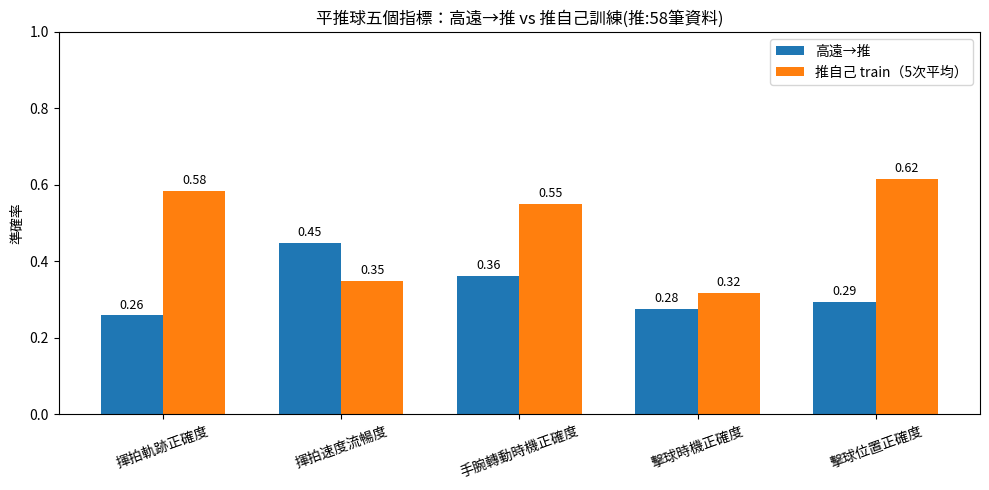

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

x = np.arange(len(plot_compare_df["指標"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    plot_compare_df["高遠_to_推_acc"],
    width,
    label="高遠→推"
)

bars2 = plt.bar(
    x + width/2,
    plot_compare_df["平推自己train_mean_acc"],
    width,
    label="推自己 train（5次平均）"
)

plt.xticks(x, plot_compare_df["指標"], rotation=20)
plt.ylabel("準確率")
plt.title("平推球五個指標：高遠→推 vs 推自己訓練(推:58筆資料)")
plt.ylim(0, 1)
plt.legend()

def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

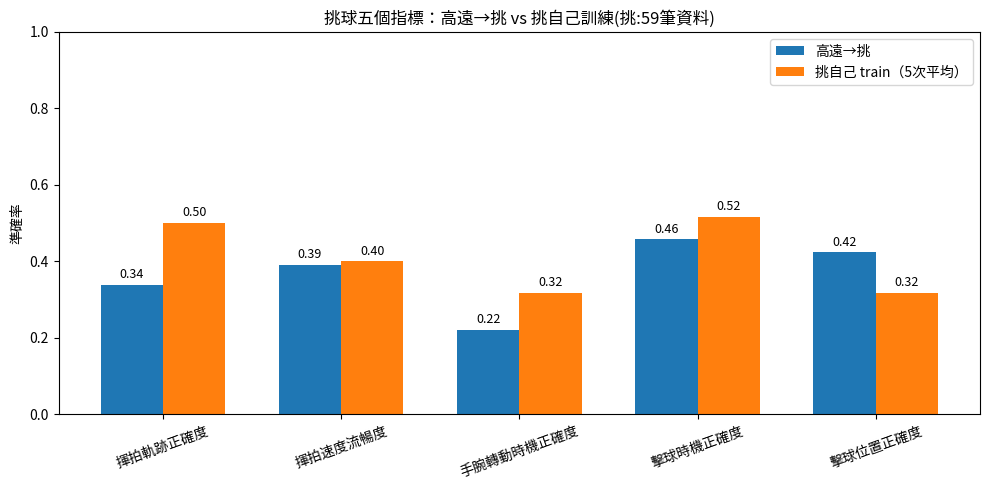

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False

x = np.arange(len(plot_compare_df["指標"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width/2,
    plot_compare_df["高遠_to_挑_acc"],
    width,
    label="高遠→挑"
)

bars2 = plt.bar(
    x + width/2,
    plot_compare_df["挑球自己train_mean_acc"],
    width,
    label="挑自己 train（5次平均）"
)

plt.xticks(x, plot_compare_df["指標"], rotation=20)
plt.ylabel("準確率")
plt.title("挑球五個指標：高遠→挑 vs 挑自己訓練(挑:59筆資料)")
plt.ylim(0, 1)
plt.legend()

def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

## 挑球 scratch 和 transfer (跑一次，揮拍軌跡正確度)
Scratch：從零訓練
Transfer：載入高遠模型 + freeze + 微調

In [35]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # ===== 固定 test set =====
# X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#     X_挑,
#     y1[挑_idx],
#     test_size=0.2,
#     random_state=42
# )

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# results = []

# # ===== Scratch =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model


# # ===== Transfer（超穩版本）=====
# def build_transfer_model(pretrained_path, num_classes=3):

#     base_model = tf.keras.models.load_model(pretrained_path)

#     # 移除最後分類層
#     base_model.pop()

#     # Freeze 所有前層
#     for layer in base_model.layers:
#         layer.trainable = False

#     # 加新分類頭
#     base_model.add(
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     )

#     base_model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return base_model


# # ===== 開始跑比例 =====
# for r in ratios:

#     n = int(len(X_train_pool) * r)
#     idx = np.random.choice(len(X_train_pool), n, replace=False)

#     X_small = X_train_pool[idx]
#     y_small = y_train_pool[idx]

#     # ---- Scratch ----
#     tf.keras.backend.clear_session()
#     scratch_model = build_scratch_model()

#     scratch_model.fit(
#         X_small, y_small,
#         epochs=100,
#         batch_size=8,
#         verbose=0
#     )

#     pred_scratch = scratch_model.predict(X_test, verbose=0)
#     acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))

#     # ---- Transfer ----
#     tf.keras.backend.clear_session()
#     transfer_model = build_transfer_model("專題/models/model1.keras")

#     transfer_model.fit(
#         X_small, y_small,
#         epochs=100,
#         batch_size=8,
#         verbose=0
#     )

#     pred_transfer = transfer_model.predict(X_test, verbose=0)
#     acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))

#     results.append({
#         "資料比例": f"{int(r*100)}%",
#         "Scratch(無高遠模型+%挑球資料集)": acc_scratch,
#         "Transfer(有高遠模型+%挑球資料集)": acc_transfer
#     })

# efficiency_df_挑 = pd.DataFrame(results)
# display(efficiency_df_挑)

## 挑球 scratch 和 transfer (跑五次，揮拍軌跡正確度)
Scratch：從零訓練
Transfer：載入高遠模型 + freeze + 微調

In [36]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # ===== 固定 test set =====
# X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#     X_挑,
#     y1[挑_idx],
#     test_size=0.2,
#     random_state=42
# )

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 5

# results = []

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(pretrained_path, num_classes=3):
#     base_model = tf.keras.models.load_model(pretrained_path)
#     base_model.pop()
#     for layer in base_model.layers:
#         layer.trainable = False
#     base_model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))
#     base_model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return base_model


# for r in ratios:

#     scratch_scores = []
#     transfer_scores = []

#     for run in range(repeat_times):

#         n = int(len(X_train_pool) * r)
#         idx = np.random.choice(len(X_train_pool), n, replace=False)

#         X_small = X_train_pool[idx]
#         y_small = y_train_pool[idx]

#         # ----- Scratch -----
#         tf.keras.backend.clear_session()
#         scratch_model = build_scratch_model()
#         scratch_model.fit(X_small, y_small, epochs=100, batch_size=8, verbose=0)

#         pred_scratch = scratch_model.predict(X_test, verbose=0)
#         acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#         scratch_scores.append(acc_scratch)

#         # ----- Transfer -----
#         tf.keras.backend.clear_session()
#         transfer_model = build_transfer_model("專題/models/model1.keras")
#         transfer_model.fit(X_small, y_small, epochs=100, batch_size=8, verbose=0)

#         pred_transfer = transfer_model.predict(X_test, verbose=0)
#         acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#         transfer_scores.append(acc_transfer)

#     results.append({
#         "資料比例": f"{int(r*100)}%",
#         "Scratch_5次": scratch_scores,
#         "Scratch_mean": np.mean(scratch_scores),
#         "Scratch_std": np.std(scratch_scores),
#         "Transfer_5次": transfer_scores,
#         "Transfer_mean": np.mean(transfer_scores),
#         "Transfer_std": np.std(transfer_scores),
#     })

# efficiency_df_挑 = pd.DataFrame(results)
# display(efficiency_df_挑)

In [37]:
# import matplotlib.pyplot as plt

# plt.errorbar(
#     ratios,
#     efficiency_df_挑["Scratch_mean"],
#     yerr=efficiency_df_挑["Scratch_std"],
#     label="Scratch",
#     marker="o"
# )

# plt.errorbar(
#     ratios,
#     efficiency_df_挑["Transfer_mean"],
#     yerr=efficiency_df_挑["Transfer_std"],
#     label="Transfer",
#     marker="o"
# )

# plt.xlabel("資料比例")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

在嚴格凍結特徵層的設定下，轉移學習在揮拍軌跡正確度的挑球任務上並沒有優於從頭訓練（scratch）。這表示高遠球與挑球之間的動作特徵可直接重用的程度相當有限。

## 平推球 scratch 和 transfer (跑五次，揮拍軌跡正確度)

In [38]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import matplotlib.pyplot as plt

# np.random.seed(42)
# tf.random.set_seed(42)

# # ===== 固定 test set =====
# X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#     X_推,
#     y1[推_idx],
#     test_size=0.2,
#     random_state=42
# )

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 5
# results = []

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(pretrained_path, num_classes=3):
#     base_model = tf.keras.models.load_model(pretrained_path)

#     # 移除最後一層
#     base_model.pop()

#     # Freeze LSTM
#     for layer in base_model.layers:
#         layer.trainable = False

#     # 加新的分類頭
#     base_model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     base_model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return base_model


# # ===== 開始跑比例 =====
# for r in ratios:

#     scratch_scores = []
#     transfer_scores = []

#     for run in range(repeat_times):

#         n = int(len(X_train_pool) * r)
#         idx = np.random.choice(len(X_train_pool), n, replace=False)

#         X_small = X_train_pool[idx]
#         y_small = y_train_pool[idx]

#         # ---- Scratch ----
#         tf.keras.backend.clear_session()
#         scratch_model = build_scratch_model()
#         scratch_model.fit(X_small, y_small, epochs=100, batch_size=8, verbose=0)

#         pred_scratch = scratch_model.predict(X_test, verbose=0)
#         acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#         scratch_scores.append(acc_scratch)

#         # ---- Transfer ----
#         tf.keras.backend.clear_session()
#         transfer_model = build_transfer_model("專題/models/model1.keras")
#         transfer_model.fit(X_small, y_small, epochs=100, batch_size=8, verbose=0)

#         pred_transfer = transfer_model.predict(X_test, verbose=0)
#         acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#         transfer_scores.append(acc_transfer)

#     results.append({
#         "資料比例": f"{int(r*100)}%",
#         "Scratch_5次": scratch_scores,
#         "Scratch_mean": np.mean(scratch_scores),
#         "Scratch_std": np.std(scratch_scores),
#         "Transfer_5次": transfer_scores,
#         "Transfer_mean": np.mean(transfer_scores),
#         "Transfer_std": np.std(transfer_scores),
#     })

# efficiency_df_推 = pd.DataFrame(results)
# display(efficiency_df_推)

In [39]:
# plt.figure(figsize=(7,5))

# plt.errorbar(
#     ratios,
#     efficiency_df_推["Scratch_mean"],
#     yerr=efficiency_df_推["Scratch_std"],
#     label="Scratch",
#     marker="o"
# )

# plt.errorbar(
#     ratios,
#     efficiency_df_推["Transfer_mean"],
#     yerr=efficiency_df_推["Transfer_std"],
#     label="Transfer",
#     marker="o"
# )

# plt.xlabel("資料比例")
# plt.ylabel("Accuracy")
# plt.title("平推球 Small Data Efficiency")
# plt.legend()
# plt.show()

## LEEP 計算 (數值越高代表 source model 越適合這個 target 任務)

揮拍軌跡正確度

In [40]:
# import numpy as np
# import tensorflow as tf

# # ===== 載入高遠模型 =====
# source_model = tf.keras.models.load_model("專題/models/model1.keras")

# def compute_leep(source_model, X_target, y_target):
    
#     # 取得 source softmax 輸出
#     source_prob = source_model.predict(X_target, verbose=0)
#     num_source_classes = source_prob.shape[1]
#     num_target_classes = len(np.unique(y_target))

#     N = len(y_target)

#     # 建立 joint matrix P(y,z)
#     joint = np.zeros((num_target_classes, num_source_classes))

#     for i in range(N):
#         for z in range(num_source_classes):
#             joint[y_target[i], z] += source_prob[i, z]

#     joint /= N

#     # P(z)
#     p_z = np.sum(joint, axis=0)

#     # P(y|z)
#     p_y_given_z = joint / (p_z + 1e-12)

#     # 計算 LEEP
#     leep = 0.0
#     for i in range(N):
#         s = 0.0
#         for z in range(num_source_classes):
#             s += p_y_given_z[y_target[i], z] * source_prob[i, z]
#         leep += np.log(s + 1e-12)

#     leep /= N
#     return leep


# # ===== 計算挑球 =====
# X_挑 = X[挑_idx]
# y_挑 = y1[挑_idx]

# leep_挑 = compute_leep(source_model, X_挑, y_挑)

# # ===== 計算平推 =====
# X_推 = X[推_idx]
# y_推 = y1[推_idx]

# leep_推 = compute_leep(source_model, X_推, y_推)

# print("挑球 LEEP:", leep_挑)
# print("平推 LEEP:", leep_推)

根據提供的論文來源，關於 LEEP 分數要接近多少才算 transfer 效果好，可以從以下幾個核心觀點來理解：
1. 分數的數值特性：越接近 0 越好
LEEP 分數在本質上是「平均對數似然值（average log-likelihood）」，因此：
- 數值永遠為負數： 根據其定義，LEEP 分數始終小於 0
- 越大（絕對值越小）越好： 較高的 LEEP 分數（即越接近 0）代表源模型與目標任務之間的遷移性（transferability）越好
2. 受目標類別數量的影響
論文指出，LEEP 分數的大小與目標任務的複雜度有關：
當目標任務包含的類別數量（classes）越多時，LEEP 分數傾向於變得更小（更負）
。因此，判斷「好」的標準會隨著任務規模而變動。
3. 實驗中的具體數值參考
從論文提供的實驗圖表（Figure 1）中，我們可以看到 LEEP 分數與實際準確率的對應關係：
- 表現優異（Level 5）： 在 ImageNet 遷移至 CIFAR100 的實驗中，LEEP 分數大約在 -1 到 -2 之間時，對應的微調（Fine-tune）準確率通常能達到 0.8 以上，重新訓練分類頭（Retrain head）的準確率則在 0.5 到 0.7 之間
- 表現較差（Level 1）： 當 LEEP 分數降至 -4 左右時，其對應的遷移準確率明顯較低

## 平推球 scratch 和 transfer (跑三次，揮拍軌跡正確度)

In [41]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # =============================
# # 🔧 改這三行跑不同維度
# # =============================
# metric_name = "揮拍軌跡正確度"
# model_path = "專題/models/model1.keras"
# y_all = y1
# # =============================

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 3
# epochs = 30

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(base_model, num_classes=3):

#     model = tf.keras.models.clone_model(base_model)
#     model.set_weights(base_model.get_weights())

#     model.pop()  # remove original head

#     for layer in model.layers:
#         layer.trainable = False

#     model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return model


# # ===== Load pretrained model once =====
# base_model_original = tf.keras.models.load_model(model_path)

# # ===== EarlyStopping =====
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="loss",
#     patience=5,
#     restore_best_weights=True
# )

# all_results = []

# for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

#     print("正在跑:", metric_name, "-", stroke_name)

#     X_target = X[idx]
#     y_target = y_all[idx]

#     X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#         X_target,
#         y_target,
#         test_size=0.2,
#         random_state=42
#     )

#     for r in ratios:

#         scratch_scores = []
#         transfer_scores = []

#         for run in range(repeat_times):

#             n = max(1, int(len(X_train_pool) * r))
#             sample_idx = np.random.choice(len(X_train_pool), n, replace=False)

#             X_small = X_train_pool[sample_idx]
#             y_small = y_train_pool[sample_idx]

#             # ---- Scratch ----
#             tf.keras.backend.clear_session()
#             scratch_model = build_scratch_model()
#             scratch_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_scratch = scratch_model.predict(X_test, verbose=0)
#             acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#             scratch_scores.append(acc_scratch)

#             # ---- Transfer ----
#             tf.keras.backend.clear_session()
#             transfer_model = build_transfer_model(base_model_original)

#             transfer_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_transfer = transfer_model.predict(X_test, verbose=0)
#             acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#             transfer_scores.append(acc_transfer)

#         all_results.append({
#             "維度": metric_name,
#             "動作": stroke_name,
#             "資料比例": f"{int(r*100)}%",
#             "Scratch_mean": np.mean(scratch_scores),
#             "Scratch_std": np.std(scratch_scores),
#             "Transfer_mean": np.mean(transfer_scores),
#             "Transfer_std": np.std(transfer_scores),
#         })

# result_df = pd.DataFrame(all_results)
# display(result_df)

# # 存檔
# result_df.to_csv(f"{metric_name}_small_data_results.csv", index=False)

## 平推球 scratch 和 transfer (跑三次，揮拍速度流暢度)

In [42]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # =============================
# # 🔧 改這三行跑不同維度
# # =============================
# metric_name = "揮拍速度流暢度"
# model_path = "專題/models/model2.keras"
# y_all = y2
# # =============================

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 3
# epochs = 30

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(base_model, num_classes=3):

#     model = tf.keras.models.clone_model(base_model)
#     model.set_weights(base_model.get_weights())

#     model.pop()  # remove original head

#     for layer in model.layers:
#         layer.trainable = False

#     model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return model


# # ===== Load pretrained model once =====
# base_model_original = tf.keras.models.load_model(model_path)

# # ===== EarlyStopping =====
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="loss",
#     patience=5,
#     restore_best_weights=True
# )

# all_results = []

# for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

#     print("正在跑:", metric_name, "-", stroke_name)

#     X_target = X[idx]
#     y_target = y_all[idx]

#     X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#         X_target,
#         y_target,
#         test_size=0.2,
#         random_state=42
#     )

#     for r in ratios:

#         scratch_scores = []
#         transfer_scores = []

#         for run in range(repeat_times):

#             n = max(1, int(len(X_train_pool) * r))
#             sample_idx = np.random.choice(len(X_train_pool), n, replace=False)

#             X_small = X_train_pool[sample_idx]
#             y_small = y_train_pool[sample_idx]

#             # ---- Scratch ----
#             tf.keras.backend.clear_session()
#             scratch_model = build_scratch_model()
#             scratch_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_scratch = scratch_model.predict(X_test, verbose=0)
#             acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#             scratch_scores.append(acc_scratch)

#             # ---- Transfer ----
#             tf.keras.backend.clear_session()
#             transfer_model = build_transfer_model(base_model_original)

#             transfer_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_transfer = transfer_model.predict(X_test, verbose=0)
#             acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#             transfer_scores.append(acc_transfer)

#         all_results.append({
#             "維度": metric_name,
#             "動作": stroke_name,
#             "資料比例": f"{int(r*100)}%",
#             "Scratch_mean": np.mean(scratch_scores),
#             "Scratch_std": np.std(scratch_scores),
#             "Transfer_mean": np.mean(transfer_scores),
#             "Transfer_std": np.std(transfer_scores),
#         })

# result_df = pd.DataFrame(all_results)
# display(result_df)

# # 存檔
# result_df.to_csv(f"{metric_name}_small_data_results.csv", index=False)

## 平推球 scratch 和 transfer (跑三次，手腕轉動時機正確度)

In [43]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # =============================
# # 🔧 改這三行跑不同維度
# # =============================
# metric_name = "手腕轉動時機正確度"
# model_path = "專題/models/model3.keras"
# y_all = y3
# # =============================

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 3
# epochs = 30

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(base_model, num_classes=3):

#     model = tf.keras.models.clone_model(base_model)
#     model.set_weights(base_model.get_weights())

#     model.pop()  # remove original head

#     for layer in model.layers:
#         layer.trainable = False

#     model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return model


# # ===== Load pretrained model once =====
# base_model_original = tf.keras.models.load_model(model_path)

# # ===== EarlyStopping =====
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="loss",
#     patience=5,
#     restore_best_weights=True
# )

# all_results = []

# for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

#     print("正在跑:", metric_name, "-", stroke_name)

#     X_target = X[idx]
#     y_target = y_all[idx]

#     X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#         X_target,
#         y_target,
#         test_size=0.2,
#         random_state=42
#     )

#     for r in ratios:

#         scratch_scores = []
#         transfer_scores = []

#         for run in range(repeat_times):

#             n = max(1, int(len(X_train_pool) * r))
#             sample_idx = np.random.choice(len(X_train_pool), n, replace=False)

#             X_small = X_train_pool[sample_idx]
#             y_small = y_train_pool[sample_idx]

#             # ---- Scratch ----
#             tf.keras.backend.clear_session()
#             scratch_model = build_scratch_model()
#             scratch_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_scratch = scratch_model.predict(X_test, verbose=0)
#             acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#             scratch_scores.append(acc_scratch)

#             # ---- Transfer ----
#             tf.keras.backend.clear_session()
#             transfer_model = build_transfer_model(base_model_original)

#             transfer_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_transfer = transfer_model.predict(X_test, verbose=0)
#             acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#             transfer_scores.append(acc_transfer)

#         all_results.append({
#             "維度": metric_name,
#             "動作": stroke_name,
#             "資料比例": f"{int(r*100)}%",
#             "Scratch_mean": np.mean(scratch_scores),
#             "Scratch_std": np.std(scratch_scores),
#             "Transfer_mean": np.mean(transfer_scores),
#             "Transfer_std": np.std(transfer_scores),
#         })

# result_df = pd.DataFrame(all_results)
# display(result_df)

# # 存檔
# result_df.to_csv(f"{metric_name}_small_data_results.csv", index=False)

## 平推球 scratch 和 transfer (跑三次，擊球時機正確度)

In [44]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # =============================
# # 🔧 改這三行跑不同維度
# # =============================
# metric_name = "擊球時機正確度"
# model_path = "專題/models/model4.keras"
# y_all = y4
# # =============================

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 3
# epochs = 30

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(base_model, num_classes=3):

#     model = tf.keras.models.clone_model(base_model)
#     model.set_weights(base_model.get_weights())

#     model.pop()  # remove original head

#     for layer in model.layers:
#         layer.trainable = False

#     model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return model


# # ===== Load pretrained model once =====
# base_model_original = tf.keras.models.load_model(model_path)

# # ===== EarlyStopping =====
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="loss",
#     patience=5,
#     restore_best_weights=True
# )

# all_results = []

# for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

#     print("正在跑:", metric_name, "-", stroke_name)

#     X_target = X[idx]
#     y_target = y_all[idx]

#     X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#         X_target,
#         y_target,
#         test_size=0.2,
#         random_state=42
#     )

#     for r in ratios:

#         scratch_scores = []
#         transfer_scores = []

#         for run in range(repeat_times):

#             n = max(1, int(len(X_train_pool) * r))
#             sample_idx = np.random.choice(len(X_train_pool), n, replace=False)

#             X_small = X_train_pool[sample_idx]
#             y_small = y_train_pool[sample_idx]

#             # ---- Scratch ----
#             tf.keras.backend.clear_session()
#             scratch_model = build_scratch_model()
#             scratch_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_scratch = scratch_model.predict(X_test, verbose=0)
#             acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#             scratch_scores.append(acc_scratch)

#             # ---- Transfer ----
#             tf.keras.backend.clear_session()
#             transfer_model = build_transfer_model(base_model_original)

#             transfer_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_transfer = transfer_model.predict(X_test, verbose=0)
#             acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#             transfer_scores.append(acc_transfer)

#         all_results.append({
#             "維度": metric_name,
#             "動作": stroke_name,
#             "資料比例": f"{int(r*100)}%",
#             "Scratch_mean": np.mean(scratch_scores),
#             "Scratch_std": np.std(scratch_scores),
#             "Transfer_mean": np.mean(transfer_scores),
#             "Transfer_std": np.std(transfer_scores),
#         })

# result_df = pd.DataFrame(all_results)
# display(result_df)

# # 存檔
# result_df.to_csv(f"{metric_name}_small_data_results.csv", index=False)

## 平推球 scratch 和 transfer (跑三次，擊球位置正確度)

In [45]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# np.random.seed(42)
# tf.random.set_seed(42)

# # =============================
# # 🔧 改這三行跑不同維度
# # =============================
# metric_name = "擊球位置正確度"
# model_path = "專題/models/model5.keras"
# y_all = y5
# # =============================

# ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
# repeat_times = 3
# epochs = 30

# # ===== Scratch model =====
# def build_scratch_model(input_shape=(100,6), num_classes=3):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),
#         tf.keras.layers.LSTM(16),
#         tf.keras.layers.Dropout(0.2),
#         tf.keras.layers.Dense(num_classes, activation="softmax")
#     ])
#     model.compile(
#         optimizer="adam",
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

# # ===== Transfer model =====
# def build_transfer_model(base_model, num_classes=3):

#     model = tf.keras.models.clone_model(base_model)
#     model.set_weights(base_model.get_weights())

#     model.pop()  # remove original head

#     for layer in model.layers:
#         layer.trainable = False

#     model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )

#     return model


# # ===== Load pretrained model once =====
# base_model_original = tf.keras.models.load_model(model_path)

# # ===== EarlyStopping =====
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="loss",
#     patience=5,
#     restore_best_weights=True
# )

# all_results = []

# for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

#     print("正在跑:", metric_name, "-", stroke_name)

#     X_target = X[idx]
#     y_target = y_all[idx]

#     X_train_pool, X_test, y_train_pool, y_test = train_test_split(
#         X_target,
#         y_target,
#         test_size=0.2,
#         random_state=42
#     )

#     for r in ratios:

#         scratch_scores = []
#         transfer_scores = []

#         for run in range(repeat_times):

#             n = max(1, int(len(X_train_pool) * r))
#             sample_idx = np.random.choice(len(X_train_pool), n, replace=False)

#             X_small = X_train_pool[sample_idx]
#             y_small = y_train_pool[sample_idx]

#             # ---- Scratch ----
#             tf.keras.backend.clear_session()
#             scratch_model = build_scratch_model()
#             scratch_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_scratch = scratch_model.predict(X_test, verbose=0)
#             acc_scratch = accuracy_score(y_test, np.argmax(pred_scratch, axis=1))
#             scratch_scores.append(acc_scratch)

#             # ---- Transfer ----
#             tf.keras.backend.clear_session()
#             transfer_model = build_transfer_model(base_model_original)

#             transfer_model.fit(
#                 X_small, y_small,
#                 epochs=epochs,
#                 batch_size=8,
#                 verbose=0,
#                 callbacks=[early_stop]
#             )

#             pred_transfer = transfer_model.predict(X_test, verbose=0)
#             acc_transfer = accuracy_score(y_test, np.argmax(pred_transfer, axis=1))
#             transfer_scores.append(acc_transfer)

#         all_results.append({
#             "維度": metric_name,
#             "動作": stroke_name,
#             "資料比例": f"{int(r*100)}%",
#             "Scratch_mean": np.mean(scratch_scores),
#             "Scratch_std": np.std(scratch_scores),
#             "Transfer_mean": np.mean(transfer_scores),
#             "Transfer_std": np.std(transfer_scores),
#         })

# result_df = pd.DataFrame(all_results)
# display(result_df)

# # 存檔
# result_df.to_csv(f"{metric_name}_small_data_results.csv", index=False)

## 全部的 LEEP (五個維度，兩種球)

In [46]:
import numpy as np
import pandas as pd
import tensorflow as tf

# ===== 維度與模型對應 =====
metric_names = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

model_paths = [
    "專題/models/model1.keras",
    "專題/models/model2.keras",
    "專題/models/model3.keras",
    "專題/models/model4.keras",
    "專題/models/model5.keras",
]

y_list = [y1, y2, y3, y4, y5]

# ===== LEEP 計算函數 =====
def compute_leep(source_model, X_target, y_target):
    
    source_prob = source_model.predict(X_target, verbose=0)
    num_source_classes = source_prob.shape[1]
    num_target_classes = len(np.unique(y_target))

    N = len(y_target)
    joint = np.zeros((num_target_classes, num_source_classes))

    for i in range(N):
        for z in range(num_source_classes):
            joint[y_target[i], z] += source_prob[i, z]

    joint /= N
    p_z = np.sum(joint, axis=0)
    p_y_given_z = joint / (p_z + 1e-12)

    leep = 0.0
    for i in range(N):
        s = 0.0
        for z in range(num_source_classes):
            s += p_y_given_z[y_target[i], z] * source_prob[i, z]
        leep += np.log(s + 1e-12)

    return leep / N


# ===== 開始計算 =====
leep_results = []

for metric_name, model_path, y_all in zip(metric_names, model_paths, y_list):

    print("正在計算:", metric_name)

    source_model = tf.keras.models.load_model(model_path)

    # 挑球
    X_挑 = X[挑_idx]
    y_挑 = y_all[挑_idx]
    leep_挑 = compute_leep(source_model, X_挑, y_挑)

    # 平推
    X_推 = X[推_idx]
    y_推 = y_all[推_idx]
    leep_推 = compute_leep(source_model, X_推, y_推)

    leep_results.append({
        "維度": metric_name,
        "挑球_LEEP": leep_挑,
        "平推_LEEP": leep_推
    })

leep_df = pd.DataFrame(leep_results)
display(leep_df)

正在計算: 揮拍軌跡正確度
正在計算: 揮拍速度流暢度
正在計算: 手腕轉動時機正確度
正在計算: 擊球時機正確度
正在計算: 擊球位置正確度


,維度,挑球_LEEP,平推_LEEP
0,揮拍軌跡正確度,-1.062441,-0.840160
1,揮拍速度流暢度,-1.072753,-0.972843
2,手腕轉動時機正確度,-1.074908,-0.925268
3,擊球時機正確度,-0.950451,-1.021854
4,擊球位置正確度,-1.014698,-0.737532


## 前面的會把以「拍」為單位切 train/test， 不是以「人」為單位切 train/test，接下來以人為單位

### model1

In [47]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# =============================
# 只先跑 model1：揮拍軌跡正確度
# =============================
metric_name = "揮拍軌跡正確度"
model_path = "專題/models/model1.keras"
y_all = y1

ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
repeat_times = 3
epochs = 30

# 從 file_name 拆出受試者 ID
# 例如 h001_44333_1 -> h001
merged_df["subject_id"] = merged_df["file_name"].astype(str).str.split("_").str[0]

# =============================
# Scratch model
# =============================
def build_scratch_model(input_shape=(100, 6), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# Transfer model
# =============================
def build_transfer_model(base_model, num_classes=3):
    model = tf.keras.models.clone_model(base_model)
    model.set_weights(base_model.get_weights())

    model.pop()  # 拿掉原本最後一層分類頭

    for layer in model.layers:
        layer.trainable = False

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# 以人為單位切 train/test
# =============================
def subject_group_split(X_data, y_data, groups, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(
        splitter.split(X_data, y_data, groups=groups)
    )

    return train_idx, test_idx


# =============================
# 從 train pool 裡面再以人為單位抽小資料
# =============================
def sample_subject_ratio(train_idx, groups_all, ratio, seed=42):
    rng = np.random.default_rng(seed)

    train_subjects = np.array(sorted(set(groups_all.iloc[train_idx])))

    n_subjects = max(1, int(len(train_subjects) * ratio))

    sampled_subjects = rng.choice(
        train_subjects,
        size=n_subjects,
        replace=False
    )

    sampled_idx = [
        idx for idx in train_idx
        if groups_all.iloc[idx] in sampled_subjects
    ]

    return np.array(sampled_idx)


# =============================
# Load pretrained model
# =============================
base_model_original = tf.keras.models.load_model(model_path)

all_results = []

for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

    print("正在跑:", metric_name, "-", stroke_name)

    X_target = X[idx]
    y_target = y_all[idx]

    target_df = merged_df[idx].reset_index(drop=True)
    groups = target_df["subject_id"]

    # 先以人為單位切 train/test
    train_idx, test_idx = subject_group_split(
        X_target,
        y_target,
        groups,
        test_size=0.2,
        seed=42
    )

    X_test = X_target[test_idx]
    y_test = y_target[test_idx]

    print("train subjects:", groups.iloc[train_idx].nunique())
    print("test subjects:", groups.iloc[test_idx].nunique())
    print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))

    for r in ratios:

        scratch_scores = []
        transfer_scores = []

        for run in range(repeat_times):

            seed = 42 + run

            small_idx = sample_subject_ratio(
                train_idx=train_idx,
                groups_all=groups,
                ratio=r,
                seed=seed
            )

            X_small = X_target[small_idx]
            y_small = y_target[small_idx]

            print(
                f"{stroke_name} | ratio {int(r*100)}% | run {run+1} | "
                f"train samples: {len(X_small)} | "
                f"train subjects: {groups.iloc[small_idx].nunique()}"
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="loss",
                patience=5,
                restore_best_weights=True
            )

            # ---- Scratch ----
            tf.keras.backend.clear_session()
            scratch_model = build_scratch_model(
                input_shape=X_target.shape[1:]
            )

            scratch_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_scratch = scratch_model.predict(X_test, verbose=0)
            acc_scratch = accuracy_score(
                y_test,
                np.argmax(pred_scratch, axis=1)
            )

            scratch_scores.append(acc_scratch)

            # ---- Transfer ----
            tf.keras.backend.clear_session()
            transfer_model = build_transfer_model(base_model_original)

            transfer_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_transfer = transfer_model.predict(X_test, verbose=0)
            acc_transfer = accuracy_score(
                y_test,
                np.argmax(pred_transfer, axis=1)
            )

            transfer_scores.append(acc_transfer)

        all_results.append({
            "維度": metric_name,
            "動作": stroke_name,
            "資料比例": f"{int(r*100)}%",
            "Scratch_mean": np.mean(scratch_scores),
            "Scratch_std": np.std(scratch_scores),
            "Transfer_mean": np.mean(transfer_scores),
            "Transfer_std": np.std(transfer_scores),
            "測試方式": "subject-based split"
        })

result_df = pd.DataFrame(all_results)
display(result_df)

result_df.to_csv(
    f"{metric_name}_以人為單位_finetune_results.csv",
    index=False,
    encoding="utf-8-sig"
)

正在跑: 揮拍軌跡正確度 - 挑球
train subjects: 47
test subjects: 12
overlap: set()
挑球 | ratio 10% | run 1 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 2 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 3 | train samples: 4 | train subjects: 4
挑球 | ratio 20% | run 1 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 2 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 3 | train samples: 9 | train subjects: 9
挑球 | ratio 30% | run 1 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 2 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 3 | train samples: 14 | train subjects: 14
挑球 | ratio 40% | run 1 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 2 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 3 | train samples: 18 | train subjects: 18
挑球 | ratio 50% | run 1 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 2 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 3 | train samples: 23 | t

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,揮拍軌跡正確度,挑球,10%,0.388889,0.141639,0.277778,0.039284,subject-based split
1,揮拍軌跡正確度,挑球,20%,0.305556,0.141639,0.333333,0.180021,subject-based split
2,揮拍軌跡正確度,挑球,30%,0.361111,0.078567,0.277778,0.039284,subject-based split
3,揮拍軌跡正確度,挑球,40%,0.500000,0.068041,0.222222,0.078567,subject-based split
4,揮拍軌跡正確度,挑球,50%,0.388889,0.171234,0.305556,0.141639,subject-based split
5,揮拍軌跡正確度,平推,10%,0.166667,0.117851,0.416667,0.136083,subject-based split
6,揮拍軌跡正確度,平推,20%,0.555556,0.103935,0.333333,0.180021,subject-based split
7,揮拍軌跡正確度,平推,30%,0.527778,0.257601,0.416667,0.117851,subject-based split
8,揮拍軌跡正確度,平推,40%,0.611111,0.103935,0.250000,0.204124,subject-based split
9,揮拍軌跡正確度,平推,50%,0.638889,0.157135,0.250000,0.136083,subject-based split


### model2

In [48]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# =============================
# 只先跑 model1：揮拍軌跡正確度
# =============================
metric_name = "揮拍速度流暢度"
model_path = "專題/models/model2.keras"
y_all = y2

ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
repeat_times = 3
epochs = 30

# 從 file_name 拆出受試者 ID
# 例如 h001_44333_1 -> h001
merged_df["subject_id"] = merged_df["file_name"].astype(str).str.split("_").str[0]

# =============================
# Scratch model
# =============================
def build_scratch_model(input_shape=(100, 6), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# Transfer model
# =============================
def build_transfer_model(base_model, num_classes=3):
    model = tf.keras.models.clone_model(base_model)
    model.set_weights(base_model.get_weights())

    model.pop()  # 拿掉原本最後一層分類頭

    for layer in model.layers:
        layer.trainable = False

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# 以人為單位切 train/test
# =============================
def subject_group_split(X_data, y_data, groups, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(
        splitter.split(X_data, y_data, groups=groups)
    )

    return train_idx, test_idx


# =============================
# 從 train pool 裡面再以人為單位抽小資料
# =============================
def sample_subject_ratio(train_idx, groups_all, ratio, seed=42):
    rng = np.random.default_rng(seed)

    train_subjects = np.array(sorted(set(groups_all.iloc[train_idx])))

    n_subjects = max(1, int(len(train_subjects) * ratio))

    sampled_subjects = rng.choice(
        train_subjects,
        size=n_subjects,
        replace=False
    )

    sampled_idx = [
        idx for idx in train_idx
        if groups_all.iloc[idx] in sampled_subjects
    ]

    return np.array(sampled_idx)


# =============================
# Load pretrained model
# =============================
base_model_original = tf.keras.models.load_model(model_path)

all_results = []

for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

    print("正在跑:", metric_name, "-", stroke_name)

    X_target = X[idx]
    y_target = y_all[idx]

    target_df = merged_df[idx].reset_index(drop=True)
    groups = target_df["subject_id"]

    # 先以人為單位切 train/test
    train_idx, test_idx = subject_group_split(
        X_target,
        y_target,
        groups,
        test_size=0.2,
        seed=42
    )

    X_test = X_target[test_idx]
    y_test = y_target[test_idx]

    print("train subjects:", groups.iloc[train_idx].nunique())
    print("test subjects:", groups.iloc[test_idx].nunique())
    print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))

    for r in ratios:

        scratch_scores = []
        transfer_scores = []

        for run in range(repeat_times):

            seed = 42 + run

            small_idx = sample_subject_ratio(
                train_idx=train_idx,
                groups_all=groups,
                ratio=r,
                seed=seed
            )

            X_small = X_target[small_idx]
            y_small = y_target[small_idx]

            print(
                f"{stroke_name} | ratio {int(r*100)}% | run {run+1} | "
                f"train samples: {len(X_small)} | "
                f"train subjects: {groups.iloc[small_idx].nunique()}"
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="loss",
                patience=5,
                restore_best_weights=True
            )

            # ---- Scratch ----
            tf.keras.backend.clear_session()
            scratch_model = build_scratch_model(
                input_shape=X_target.shape[1:]
            )

            scratch_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_scratch = scratch_model.predict(X_test, verbose=0)
            acc_scratch = accuracy_score(
                y_test,
                np.argmax(pred_scratch, axis=1)
            )

            scratch_scores.append(acc_scratch)

            # ---- Transfer ----
            tf.keras.backend.clear_session()
            transfer_model = build_transfer_model(base_model_original)

            transfer_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_transfer = transfer_model.predict(X_test, verbose=0)
            acc_transfer = accuracy_score(
                y_test,
                np.argmax(pred_transfer, axis=1)
            )

            transfer_scores.append(acc_transfer)

        all_results.append({
            "維度": metric_name,
            "動作": stroke_name,
            "資料比例": f"{int(r*100)}%",
            "Scratch_mean": np.mean(scratch_scores),
            "Scratch_std": np.std(scratch_scores),
            "Transfer_mean": np.mean(transfer_scores),
            "Transfer_std": np.std(transfer_scores),
            "測試方式": "subject-based split"
        })

result_df = pd.DataFrame(all_results)
display(result_df)

result_df.to_csv(
    f"{metric_name}_以人為單位_finetune_results.csv",
    index=False,
    encoding="utf-8-sig"
)

正在跑: 揮拍速度流暢度 - 挑球
train subjects: 47
test subjects: 12
overlap: set()
挑球 | ratio 10% | run 1 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 2 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 3 | train samples: 4 | train subjects: 4
挑球 | ratio 20% | run 1 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 2 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 3 | train samples: 9 | train subjects: 9
挑球 | ratio 30% | run 1 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 2 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 3 | train samples: 14 | train subjects: 14
挑球 | ratio 40% | run 1 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 2 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 3 | train samples: 18 | train subjects: 18
挑球 | ratio 50% | run 1 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 2 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 3 | train samples: 23 | t

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,揮拍速度流暢度,挑球,10%,0.250000,0.068041,0.305556,0.171234,subject-based split
1,揮拍速度流暢度,挑球,20%,0.416667,0.068041,0.333333,0.068041,subject-based split
2,揮拍速度流暢度,挑球,30%,0.305556,0.171234,0.305556,0.039284,subject-based split
3,揮拍速度流暢度,挑球,40%,0.388889,0.141639,0.305556,0.078567,subject-based split
4,揮拍速度流暢度,挑球,50%,0.472222,0.196419,0.361111,0.103935,subject-based split
5,揮拍速度流暢度,平推,10%,0.388889,0.039284,0.305556,0.103935,subject-based split
6,揮拍速度流暢度,平推,20%,0.527778,0.078567,0.194444,0.141639,subject-based split
7,揮拍速度流暢度,平推,30%,0.361111,0.103935,0.500000,0.068041,subject-based split
8,揮拍速度流暢度,平推,40%,0.333333,0.068041,0.388889,0.078567,subject-based split
9,揮拍速度流暢度,平推,50%,0.416667,0.000000,0.305556,0.078567,subject-based split


### model3

In [49]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# =============================
# 只先跑 model1：揮拍軌跡正確度
# =============================
metric_name = "手腕轉動時機正確度"
model_path = "專題/models/model3.keras"
y_all = y3

ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
repeat_times = 3
epochs = 30

# 從 file_name 拆出受試者 ID
# 例如 h001_44333_1 -> h001
merged_df["subject_id"] = merged_df["file_name"].astype(str).str.split("_").str[0]

# =============================
# Scratch model
# =============================
def build_scratch_model(input_shape=(100, 6), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# Transfer model
# =============================
def build_transfer_model(base_model, num_classes=3):
    model = tf.keras.models.clone_model(base_model)
    model.set_weights(base_model.get_weights())

    model.pop()  # 拿掉原本最後一層分類頭

    for layer in model.layers:
        layer.trainable = False

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# 以人為單位切 train/test
# =============================
def subject_group_split(X_data, y_data, groups, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(
        splitter.split(X_data, y_data, groups=groups)
    )

    return train_idx, test_idx


# =============================
# 從 train pool 裡面再以人為單位抽小資料
# =============================
def sample_subject_ratio(train_idx, groups_all, ratio, seed=42):
    rng = np.random.default_rng(seed)

    train_subjects = np.array(sorted(set(groups_all.iloc[train_idx])))

    n_subjects = max(1, int(len(train_subjects) * ratio))

    sampled_subjects = rng.choice(
        train_subjects,
        size=n_subjects,
        replace=False
    )

    sampled_idx = [
        idx for idx in train_idx
        if groups_all.iloc[idx] in sampled_subjects
    ]

    return np.array(sampled_idx)


# =============================
# Load pretrained model
# =============================
base_model_original = tf.keras.models.load_model(model_path)

all_results = []

for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

    print("正在跑:", metric_name, "-", stroke_name)

    X_target = X[idx]
    y_target = y_all[idx]

    target_df = merged_df[idx].reset_index(drop=True)
    groups = target_df["subject_id"]

    # 先以人為單位切 train/test
    train_idx, test_idx = subject_group_split(
        X_target,
        y_target,
        groups,
        test_size=0.2,
        seed=42
    )

    X_test = X_target[test_idx]
    y_test = y_target[test_idx]

    print("train subjects:", groups.iloc[train_idx].nunique())
    print("test subjects:", groups.iloc[test_idx].nunique())
    print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))

    for r in ratios:

        scratch_scores = []
        transfer_scores = []

        for run in range(repeat_times):

            seed = 42 + run

            small_idx = sample_subject_ratio(
                train_idx=train_idx,
                groups_all=groups,
                ratio=r,
                seed=seed
            )

            X_small = X_target[small_idx]
            y_small = y_target[small_idx]

            print(
                f"{stroke_name} | ratio {int(r*100)}% | run {run+1} | "
                f"train samples: {len(X_small)} | "
                f"train subjects: {groups.iloc[small_idx].nunique()}"
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="loss",
                patience=5,
                restore_best_weights=True
            )

            # ---- Scratch ----
            tf.keras.backend.clear_session()
            scratch_model = build_scratch_model(
                input_shape=X_target.shape[1:]
            )

            scratch_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_scratch = scratch_model.predict(X_test, verbose=0)
            acc_scratch = accuracy_score(
                y_test,
                np.argmax(pred_scratch, axis=1)
            )

            scratch_scores.append(acc_scratch)

            # ---- Transfer ----
            tf.keras.backend.clear_session()
            transfer_model = build_transfer_model(base_model_original)

            transfer_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_transfer = transfer_model.predict(X_test, verbose=0)
            acc_transfer = accuracy_score(
                y_test,
                np.argmax(pred_transfer, axis=1)
            )

            transfer_scores.append(acc_transfer)

        all_results.append({
            "維度": metric_name,
            "動作": stroke_name,
            "資料比例": f"{int(r*100)}%",
            "Scratch_mean": np.mean(scratch_scores),
            "Scratch_std": np.std(scratch_scores),
            "Transfer_mean": np.mean(transfer_scores),
            "Transfer_std": np.std(transfer_scores),
            "測試方式": "subject-based split"
        })

result_df = pd.DataFrame(all_results)
display(result_df)

result_df.to_csv(
    f"{metric_name}_以人為單位_finetune_results.csv",
    index=False,
    encoding="utf-8-sig"
)

正在跑: 手腕轉動時機正確度 - 挑球
train subjects: 47
test subjects: 12
overlap: set()
挑球 | ratio 10% | run 1 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 2 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 3 | train samples: 4 | train subjects: 4
挑球 | ratio 20% | run 1 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 2 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 3 | train samples: 9 | train subjects: 9
挑球 | ratio 30% | run 1 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 2 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 3 | train samples: 14 | train subjects: 14
挑球 | ratio 40% | run 1 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 2 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 3 | train samples: 18 | train subjects: 18
挑球 | ratio 50% | run 1 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 2 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 3 | train samples: 23 |

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,手腕轉動時機正確度,挑球,10%,0.388889,0.103935,0.305556,0.171234,subject-based split
1,手腕轉動時機正確度,挑球,20%,0.333333,0.245327,0.416667,0.068041,subject-based split
2,手腕轉動時機正確度,挑球,30%,0.361111,0.306816,0.277778,0.078567,subject-based split
3,手腕轉動時機正確度,挑球,40%,0.388889,0.039284,0.305556,0.171234,subject-based split
4,手腕轉動時機正確度,挑球,50%,0.388889,0.103935,0.388889,0.078567,subject-based split
5,手腕轉動時機正確度,平推,10%,0.333333,0.180021,0.583333,0.117851,subject-based split
6,手腕轉動時機正確度,平推,20%,0.388889,0.103935,0.361111,0.141639,subject-based split
7,手腕轉動時機正確度,平推,30%,0.416667,0.136083,0.333333,0.000000,subject-based split
8,手腕轉動時機正確度,平推,40%,0.416667,0.136083,0.250000,0.117851,subject-based split
9,手腕轉動時機正確度,平推,50%,0.388889,0.141639,0.277778,0.218722,subject-based split


### model4

In [50]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# =============================
# 只先跑 model1：揮拍軌跡正確度
# =============================
metric_name = "擊球時機正確度"
model_path = "專題/models/model4.keras"
y_all = y4

ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
repeat_times = 3
epochs = 30

# 從 file_name 拆出受試者 ID
# 例如 h001_44333_1 -> h001
merged_df["subject_id"] = merged_df["file_name"].astype(str).str.split("_").str[0]

# =============================
# Scratch model
# =============================
def build_scratch_model(input_shape=(100, 6), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# Transfer model
# =============================
def build_transfer_model(base_model, num_classes=3):
    model = tf.keras.models.clone_model(base_model)
    model.set_weights(base_model.get_weights())

    model.pop()  # 拿掉原本最後一層分類頭

    for layer in model.layers:
        layer.trainable = False

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# 以人為單位切 train/test
# =============================
def subject_group_split(X_data, y_data, groups, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(
        splitter.split(X_data, y_data, groups=groups)
    )

    return train_idx, test_idx


# =============================
# 從 train pool 裡面再以人為單位抽小資料
# =============================
def sample_subject_ratio(train_idx, groups_all, ratio, seed=42):
    rng = np.random.default_rng(seed)

    train_subjects = np.array(sorted(set(groups_all.iloc[train_idx])))

    n_subjects = max(1, int(len(train_subjects) * ratio))

    sampled_subjects = rng.choice(
        train_subjects,
        size=n_subjects,
        replace=False
    )

    sampled_idx = [
        idx for idx in train_idx
        if groups_all.iloc[idx] in sampled_subjects
    ]

    return np.array(sampled_idx)


# =============================
# Load pretrained model
# =============================
base_model_original = tf.keras.models.load_model(model_path)

all_results = []

for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

    print("正在跑:", metric_name, "-", stroke_name)

    X_target = X[idx]
    y_target = y_all[idx]

    target_df = merged_df[idx].reset_index(drop=True)
    groups = target_df["subject_id"]

    # 先以人為單位切 train/test
    train_idx, test_idx = subject_group_split(
        X_target,
        y_target,
        groups,
        test_size=0.2,
        seed=42
    )

    X_test = X_target[test_idx]
    y_test = y_target[test_idx]

    print("train subjects:", groups.iloc[train_idx].nunique())
    print("test subjects:", groups.iloc[test_idx].nunique())
    print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))

    for r in ratios:

        scratch_scores = []
        transfer_scores = []

        for run in range(repeat_times):

            seed = 42 + run

            small_idx = sample_subject_ratio(
                train_idx=train_idx,
                groups_all=groups,
                ratio=r,
                seed=seed
            )

            X_small = X_target[small_idx]
            y_small = y_target[small_idx]

            print(
                f"{stroke_name} | ratio {int(r*100)}% | run {run+1} | "
                f"train samples: {len(X_small)} | "
                f"train subjects: {groups.iloc[small_idx].nunique()}"
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="loss",
                patience=5,
                restore_best_weights=True
            )

            # ---- Scratch ----
            tf.keras.backend.clear_session()
            scratch_model = build_scratch_model(
                input_shape=X_target.shape[1:]
            )

            scratch_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_scratch = scratch_model.predict(X_test, verbose=0)
            acc_scratch = accuracy_score(
                y_test,
                np.argmax(pred_scratch, axis=1)
            )

            scratch_scores.append(acc_scratch)

            # ---- Transfer ----
            tf.keras.backend.clear_session()
            transfer_model = build_transfer_model(base_model_original)

            transfer_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_transfer = transfer_model.predict(X_test, verbose=0)
            acc_transfer = accuracy_score(
                y_test,
                np.argmax(pred_transfer, axis=1)
            )

            transfer_scores.append(acc_transfer)

        all_results.append({
            "維度": metric_name,
            "動作": stroke_name,
            "資料比例": f"{int(r*100)}%",
            "Scratch_mean": np.mean(scratch_scores),
            "Scratch_std": np.std(scratch_scores),
            "Transfer_mean": np.mean(transfer_scores),
            "Transfer_std": np.std(transfer_scores),
            "測試方式": "subject-based split"
        })

result_df = pd.DataFrame(all_results)
display(result_df)

result_df.to_csv(
    f"{metric_name}_以人為單位_finetune_results.csv",
    index=False,
    encoding="utf-8-sig"
)

正在跑: 擊球時機正確度 - 挑球
train subjects: 47
test subjects: 12
overlap: set()
挑球 | ratio 10% | run 1 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 2 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 3 | train samples: 4 | train subjects: 4
挑球 | ratio 20% | run 1 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 2 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 3 | train samples: 9 | train subjects: 9
挑球 | ratio 30% | run 1 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 2 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 3 | train samples: 14 | train subjects: 14
挑球 | ratio 40% | run 1 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 2 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 3 | train samples: 18 | train subjects: 18
挑球 | ratio 50% | run 1 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 2 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 3 | train samples: 23 | t

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,擊球時機正確度,挑球,10%,0.361111,0.103935,0.250000,0.245327,subject-based split
1,擊球時機正確度,挑球,20%,0.416667,0.180021,0.138889,0.103935,subject-based split
2,擊球時機正確度,挑球,30%,0.444444,0.103935,0.527778,0.039284,subject-based split
3,擊球時機正確度,挑球,40%,0.555556,0.039284,0.444444,0.103935,subject-based split
4,擊球時機正確度,挑球,50%,0.611111,0.039284,0.444444,0.196419,subject-based split
5,擊球時機正確度,平推,10%,0.194444,0.103935,0.222222,0.039284,subject-based split
6,擊球時機正確度,平推,20%,0.333333,0.068041,0.277778,0.141639,subject-based split
7,擊球時機正確度,平推,30%,0.305556,0.078567,0.305556,0.039284,subject-based split
8,擊球時機正確度,平推,40%,0.361111,0.039284,0.305556,0.141639,subject-based split
9,擊球時機正確度,平推,50%,0.333333,0.117851,0.166667,0.136083,subject-based split


### model5

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# =============================
# 只先跑 model1：揮拍軌跡正確度
# =============================
metric_name = "擊球位置正確度"
model_path = "專題/models/model5.keras"
y_all = y5

ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
repeat_times = 3
epochs = 30

# 從 file_name 拆出受試者 ID
# 例如 h001_44333_1 -> h001
merged_df["subject_id"] = merged_df["file_name"].astype(str).str.split("_").str[0]

# =============================
# Scratch model
# =============================
def build_scratch_model(input_shape=(100, 6), num_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# Transfer model
# =============================
def build_transfer_model(base_model, num_classes=3):
    model = tf.keras.models.clone_model(base_model)
    model.set_weights(base_model.get_weights())

    model.pop()  # 拿掉原本最後一層分類頭

    for layer in model.layers:
        layer.trainable = False

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =============================
# 以人為單位切 train/test
# =============================
def subject_group_split(X_data, y_data, groups, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed
    )

    train_idx, test_idx = next(
        splitter.split(X_data, y_data, groups=groups)
    )

    return train_idx, test_idx


# =============================
# 從 train pool 裡面再以人為單位抽小資料
# =============================
def sample_subject_ratio(train_idx, groups_all, ratio, seed=42):
    rng = np.random.default_rng(seed)

    train_subjects = np.array(sorted(set(groups_all.iloc[train_idx])))

    n_subjects = max(1, int(len(train_subjects) * ratio))

    sampled_subjects = rng.choice(
        train_subjects,
        size=n_subjects,
        replace=False
    )

    sampled_idx = [
        idx for idx in train_idx
        if groups_all.iloc[idx] in sampled_subjects
    ]

    return np.array(sampled_idx)


# =============================
# Load pretrained model
# =============================
base_model_original = tf.keras.models.load_model(model_path)

all_results = []

for stroke_name, idx in [("挑球", 挑_idx), ("平推", 推_idx)]:

    print("正在跑:", metric_name, "-", stroke_name)

    X_target = X[idx]
    y_target = y_all[idx]

    target_df = merged_df[idx].reset_index(drop=True)
    groups = target_df["subject_id"]

    # 先以人為單位切 train/test
    train_idx, test_idx = subject_group_split(
        X_target,
        y_target,
        groups,
        test_size=0.2,
        seed=42
    )

    X_test = X_target[test_idx]
    y_test = y_target[test_idx]

    print("train subjects:", groups.iloc[train_idx].nunique())
    print("test subjects:", groups.iloc[test_idx].nunique())
    print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))

    for r in ratios:

        scratch_scores = []
        transfer_scores = []

        for run in range(repeat_times):

            seed = 42 + run

            small_idx = sample_subject_ratio(
                train_idx=train_idx,
                groups_all=groups,
                ratio=r,
                seed=seed
            )

            X_small = X_target[small_idx]
            y_small = y_target[small_idx]

            print(
                f"{stroke_name} | ratio {int(r*100)}% | run {run+1} | "
                f"train samples: {len(X_small)} | "
                f"train subjects: {groups.iloc[small_idx].nunique()}"
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="loss",
                patience=5,
                restore_best_weights=True
            )

            # ---- Scratch ----
            tf.keras.backend.clear_session()
            scratch_model = build_scratch_model(
                input_shape=X_target.shape[1:]
            )

            scratch_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_scratch = scratch_model.predict(X_test, verbose=0)
            acc_scratch = accuracy_score(
                y_test,
                np.argmax(pred_scratch, axis=1)
            )

            scratch_scores.append(acc_scratch)

            # ---- Transfer ----
            tf.keras.backend.clear_session()
            transfer_model = build_transfer_model(base_model_original)

            transfer_model.fit(
                X_small,
                y_small,
                epochs=epochs,
                batch_size=8,
                verbose=0,
                callbacks=[early_stop]
            )

            pred_transfer = transfer_model.predict(X_test, verbose=0)
            acc_transfer = accuracy_score(
                y_test,
                np.argmax(pred_transfer, axis=1)
            )

            transfer_scores.append(acc_transfer)

        all_results.append({
            "維度": metric_name,
            "動作": stroke_name,
            "資料比例": f"{int(r*100)}%",
            "Scratch_mean": np.mean(scratch_scores),
            "Scratch_std": np.std(scratch_scores),
            "Transfer_mean": np.mean(transfer_scores),
            "Transfer_std": np.std(transfer_scores),
            "測試方式": "subject-based split"
        })

result_df = pd.DataFrame(all_results)
display(result_df)

result_df.to_csv(
    f"{metric_name}_以人為單位_finetune_results.csv",
    index=False,
    encoding="utf-8-sig"
)

正在跑: 擊球位置正確度 - 挑球
train subjects: 47
test subjects: 12
overlap: set()
挑球 | ratio 10% | run 1 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 2 | train samples: 4 | train subjects: 4
挑球 | ratio 10% | run 3 | train samples: 4 | train subjects: 4
挑球 | ratio 20% | run 1 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 2 | train samples: 9 | train subjects: 9
挑球 | ratio 20% | run 3 | train samples: 9 | train subjects: 9
挑球 | ratio 30% | run 1 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 2 | train samples: 14 | train subjects: 14
挑球 | ratio 30% | run 3 | train samples: 14 | train subjects: 14
挑球 | ratio 40% | run 1 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 2 | train samples: 18 | train subjects: 18
挑球 | ratio 40% | run 3 | train samples: 18 | train subjects: 18
挑球 | ratio 50% | run 1 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 2 | train samples: 23 | train subjects: 23
挑球 | ratio 50% | run 3 | train samples: 23 | t

,維度,動作,資料比例,Scratch_mean,Scratch_std,Transfer_mean,Transfer_std,測試方式
0,擊球位置正確度,挑球,10%,0.305556,0.039284,0.222222,0.078567,subject-based split
1,擊球位置正確度,挑球,20%,0.250000,0.000000,0.333333,0.180021,subject-based split
2,擊球位置正確度,挑球,30%,0.416667,0.000000,0.388889,0.103935,subject-based split
3,擊球位置正確度,挑球,40%,0.333333,0.068041,0.333333,0.068041,subject-based split
4,擊球位置正確度,挑球,50%,0.333333,0.068041,0.305556,0.078567,subject-based split
5,擊球位置正確度,平推,10%,0.444444,0.078567,0.333333,0.235702,subject-based split
6,擊球位置正確度,平推,20%,0.472222,0.103935,0.277778,0.238953,subject-based split
7,擊球位置正確度,平推,30%,0.250000,0.068041,0.388889,0.078567,subject-based split
8,擊球位置正確度,平推,40%,0.444444,0.039284,0.361111,0.283279,subject-based split
9,擊球位置正確度,平推,50%,0.388889,0.103935,0.416667,0.068041,subject-based split


In [53]:
from pathlib import Path

# 先拿純檔名，不要路徑
merged_df["base_name"] = merged_df["file_name"].astype(str).apply(lambda x: Path(x).stem)

# 10281挑_1 -> 10281
# 10281推_1 -> 10281
merged_df["subject_id"] = merged_df["base_name"].str.extract(r"^(\d+)")

display(merged_df[["file_name", "base_name", "subject_id", "stroke_type_x"]].head(30))

,file_name,base_name,subject_id,stroke_type_x
0,10281挑,10281挑,10281,挑
1,10281推,10281推,10281,推
2,10282挑,10282挑,10282,挑
3,10282推,10282推,10282,推
4,10283挑,10283挑,10283,挑
5,10283推,10283推,10283,推
6,10284挑補,10284挑補,10284,挑
7,10284推補,10284推補,10284,推
8,10285挑補,10285挑補,10285,挑
9,10285推,10285推,10285,推


In [ ]:
print(merged_df.groupby(["stroke_type_x", "subject_id"]).size().head(30))
print(merged_df.groupby(["stroke_type_x", "subject_id"]).size().describe())

stroke_type_x  subject_id
挑              10281         1
               10282         1
               10283         1
               10284         1
               10285         1
               10286         1
               10287         1
               10288         1
               10301         1
               10302         1
               10303         1
               10304         1
               10305         1
               11011         1
               110110        1
               110111        1
               110112        1
               110113        1
               110114        1
               110115        1
               110116        1
               110117        1
               110118        1
               110119        1
               11012         1
               110120        1
               110121        1
               110122        1
               110123        1
               110124        1
dtype: int64
count    117.0
mean       1.0
s

: 

## 前面的資料挑球和平推有誤